# MissLearn Benchmark Test Suite

Model family comparison, real-world scenarios, and missingness mechanism sensitivity.

**This suite complements `benchmarks/`: it does not replicate it.**

| What | Where |
|------|-------|
| Drop Rows / Drop Cols / Mean / KNN / MICE vs FIML on synthetic data | `benchmarks/MissLinear_Benchmark.ipynb` (and per-algorithm notebooks) |
| All MissLearn model families compared head-to-head | **This notebook** |
| Real missing data (Auto MPG) | **This notebook** |
| MCAR / MAR / MNAR mechanism sweep | **This notebook** |
| Grouped / longitudinal data (MissMixed) | **This notebook** |
| Multi-class classification (MissMulticlass) | **This notebook** |

| Tier | Dataset | n | p | Task | Missingness | Baseline |
|------|---------|---|---|------|-------------|---------|
| 1 | Energy Efficiency | 768 | 8 | Regression | Synthetic MAR | MICE only |
| 1 | Breast Cancer Wisconsin | 569 | 10 | Binary clf | Synthetic MAR | MICE only |
| 1 | Iris | 150 | 4 | 3-class clf | Synthetic MAR | MICE only |
| 2 | Auto MPG | 392 | 7 | Regression | Real (horsepower) | CC + Mean + KNN + MICE |
| 3 | ESOL (Delaney) | 1128 | 6 | Regression | Sweep MCAR/MAR/MNAR | CC + MICE |
| 4 | Radon (Gelman) | 919 | 2 | Reg + Binary clf | Synthetic MAR, 85 groups | CC + Mean + KNN + MICE |

**Tier 1 uses a single MICE baseline**: the benchmark notebooks cover the full
CC / Mean / KNN / MICE comparison exhaustively on controlled synthetic data;
this suite keeps Tier 1 focused on comparing MissLearn model families against each other.

*GP skipped for n > 400 (O(n³) cost).  MissMixed requires a groups variable (Tier 4 only).*

Run the **Setup** cell first, then **Prepare Datasets** (downloads CSVs once).
Each benchmark cell is independent after that.

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # make MissLearn importable from tests/
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")

from benchmark_test_suite import (
    bench_energy_efficiency,
    bench_wisconsin,
    bench_iris,
    bench_auto_mpg,
    bench_esol_sweep,
    bench_mixed,
)
print("Benchmark functions loaded ✓")

---
### Prepare Datasets
Downloads all seven datasets to `tests/benchmark_data/` and saves them as CSV files.
Already-cached files are skipped automatically.  Run once before benchmarking.

**Expected download time:** ~30 to 90 s on a fast connection.  
Energy Efficiency requires an XLSX download (~100 KB).  
ESOL requires network access to GitHub raw content.  
Radon is downloaded from the Gelman ROS-Examples repository.

In [4]:
from prepare_datasets import prepare_all
prepare_all()   # pass force=True to re-download everything

Saving datasets to: C:\Users\Amanda\Favorites\Machine Learning\MissLearn\tests\benchmark_data

  energy_efficiency.csv  already exists — skipping
  wisconsin.csv           already exists — skipping
  iris.csv                already exists — skipping
  horse_colic.csv         already exists — skipping
  auto_mpg.csv            already exists — skipping
  esol.csv                already exists — skipping
  radon.csv               already exists — skipping

Summary:
  Energy Efficiency      OK
  Wisconsin              OK
  Iris                   OK
  Horse Colic            OK
  Auto MPG               OK
  ESOL                   OK
  Radon                  OK


---
## Tier 1: Model Family Comparison (Synthetic MAR)

These datasets are complete in their original form.  A fixed fraction of X values is
masked MAR before each benchmark (for feature *j*, missingness depends on whether
feature *(j+1) % p* is above or below its median).

**Focus:** which MissLearn model family performs best, and does any family struggle?
A single MICE + LinearModel baseline anchors the comparison; enough to confirm FIML
holds its ground without duplicating the exhaustive baseline coverage in `benchmarks/`.

> For the full seven-method comparison (Drop Rows, Drop Cols, Mean, KNN, MICE,
> FIML) with bar charts, strip plots, gain heatmaps and t-tests, see
> **`benchmarks/MissLinear_Benchmark.ipynb`**.

---
### 1. Energy Efficiency  (regression, synthetic MAR 20%)Residential building energy simulation dataset from UCI.  Target: heating load (kWh/m²).
Eight building geometry features, no missing values in the original.  20% MAR injected.
GP omitted (n=768 > 400).  Baseline: MICE + LinearRegression.

**Reference:** Tsanas & Xifara (2012), doi:10.1016/j.enbuild.2012.03.003  
**Defaults:** `miss_rate=0.20`, `n_splits=5`, `seed=42`


  Energy Efficiency  (Tier 1 — model family comparison, synthetic MAR)
  n=768  p=8  miss=19.1%  cv=5  seed=42
  Dataset  : Energy Efficiency  |  Tsanas & Xifara (2012)
  Task     : regression  |  target: heating load (kWh/m²)
  Baseline : MICE + LinearRegression  (see benchmarks/ for full comparison)
  GP skipped (n=768 > 400)

  Running 5-fold CV: 1 baseline + 6 MissLearn models ...

5-fold CV results
  Method                             RMSE        MAE         R²
  -------------------------------------------------------------
  MICE + LinearReg             3.4483±0.2554 2.4808±0.1514 0.8818±0.0132
  ·····························································
  MissLinear                   4.0454±0.3044 3.0930±0.2391 0.8370±0.0220
  MissRidgeRegressor           3.5009±0.2357 2.5892±0.1402 0.8783±0.0117
  MissLASSORegressor           3.4576±0.2269 2.5235±0.1486 0.8812±0.0118
  MissNeighborsRegressor       3.2188±0.2602 2.1275±0.1487 0.8965±0.0180
  MissBayesRegressor           5.16

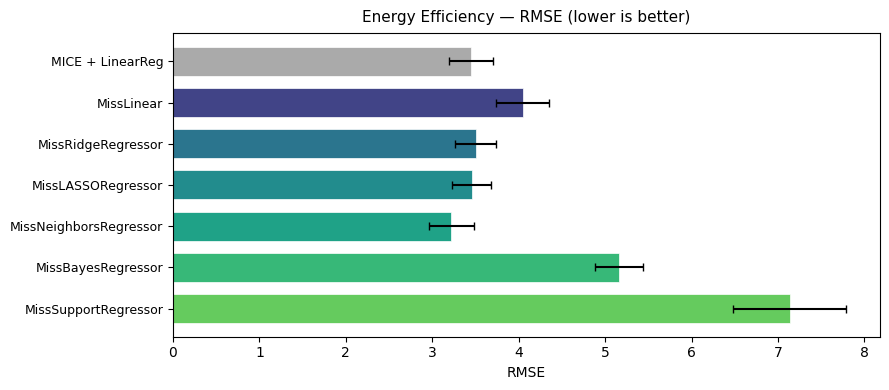

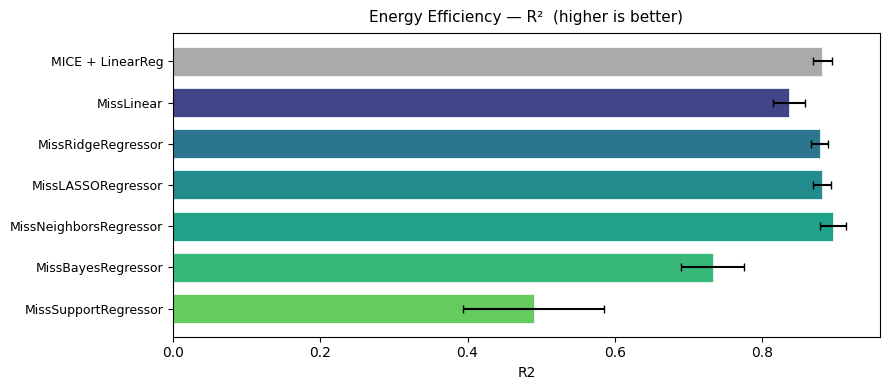

In [7]:
results_energy = bench_energy_efficiency(plot=True)

---
### 2. Breast Cancer Wisconsin  (binary classification, synthetic MAR 25%)Classic UCI benchmark for breast tumour diagnosis.  Target: malignant (1) vs benign (0).
Ten mean nuclear features from FNA images; 569 samples; positive rate ~37%.  25% MAR
injected.  GP omitted (n=569 > 400).  Baseline: MICE + LogisticRegression.

**Reference:** Street et al. (1993), doi:10.24432/C5DW2B  
**Defaults:** `miss_rate=0.25`, `n_splits=5`, `seed=42`


  Breast Cancer Wisconsin  (Tier 1 — model family comparison, synthetic MAR)
  n=569  p=10  miss=25.5%  positive=62.7%  cv=5  seed=42
  Dataset  : Wisconsin  |  Street et al. (1993)
  Task     : binary classification  |  target: malignant (0/1)
  Baseline : MICE + LogisticRegression  (see benchmarks/ for full comparison)
  GP skipped (n=569 > 400)

  Running 5-fold CV: 1 baseline + 6 MissLearn models ...

5-fold CV results
  Method                            Accuracy        AUC         F1      Brier
  ---------------------------------------------------------------------------
  MICE + LogReg                   0.9051±0.0188  0.9746±0.0136  0.9041±0.0197  0.0644±0.0146
  ···········································································
  MissLogistic                    0.9052±0.0292  0.9594±0.0184  0.9043±0.0308  0.0773±0.0183
  MissRidgeClassifier             0.8999±0.0273  0.9597±0.0178  0.8991±0.0280  0.0784±0.0169
  MissLASSOClassifier             0.9210±0.0296  0.9638±0.0

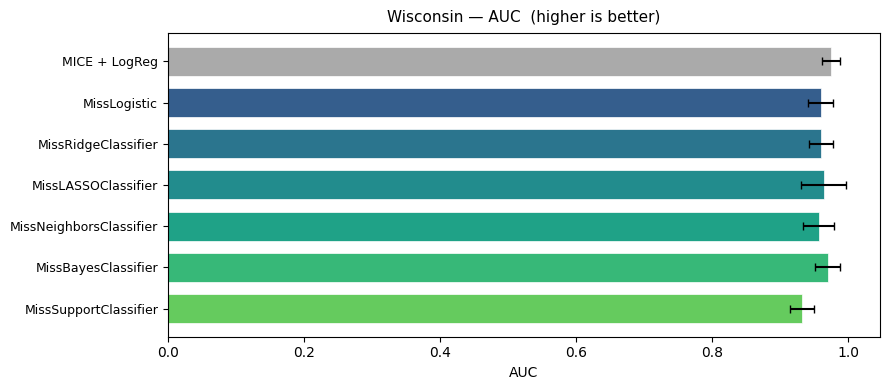

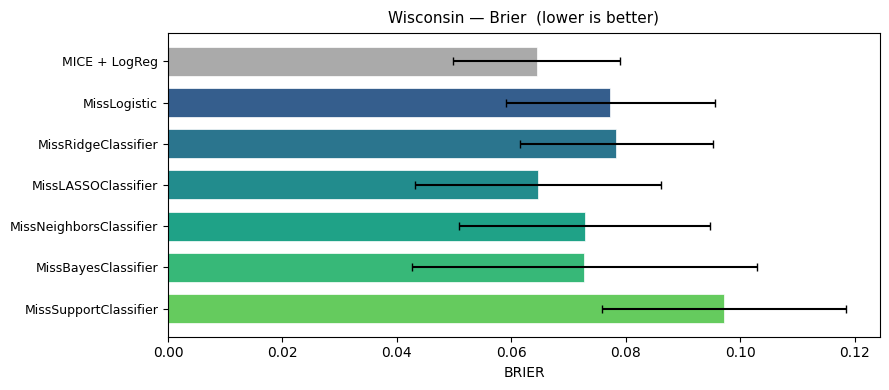

In [9]:
results_wisconsin = bench_wisconsin(plot=True)

---
### 3. Iris  (3-class classification, synthetic MAR 20%)Fisher's Iris dataset.  Four petal/sepal measurements; three balanced species classes;
n=150.  This benchmark is **unique in the suite**: all MissLearn binary classifiers are
wrapped in `MissMulticlass` (one-vs-rest), and `MissGaussianClassifier` is included
(n=150 ≤ 400 GP threshold).  AUC reported as macro one-vs-rest.
Baseline: MICE + LogisticRegression.

**Reference:** Fisher (1936), doi:10.1111/j.1469-1809.1936.tb02137.x  
**Defaults:** `miss_rate=0.20`, `n_splits=5`, `seed=42`


  Iris  (Tier 1 — model family comparison, 3-class, MissMulticlass OvR)
  n=150  p=4  miss=19.7%  cv=5  seed=42
  Dataset  : Iris  |  Fisher (1936)
  Task     : 3-class classification  |  target: species (0/1/2)
  Baseline : MICE + LogisticRegression  (see benchmarks/ for full comparison)
  MissLearn models wrapped in MissMulticlass (OvR)
  MissGaussianClassifier included (n=150 <= 400)

  Running 5-fold CV: 1 baseline + 7 MissLearn models ...

5-fold CV results  (AUC = macro OvR)
  Method                            Accuracy        AUC         F1      Brier
  ---------------------------------------------------------------------------
  MICE + LogReg                   0.9133±0.0650  0.9823±0.0217  0.9127±0.0652  0.1780±0.0473
  ···········································································
  MC(MissLogistic)                0.9667±0.0471  0.9883±0.0195  0.9665±0.0473  0.1158±0.0568
  MC(MissRidgeClassifier)         0.9400±0.0435  0.9847±0.0195  0.9393±0.0441  0.1744±0.0447


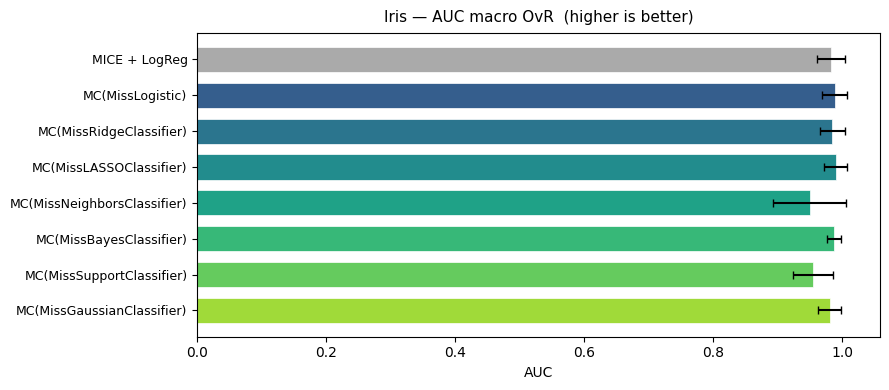

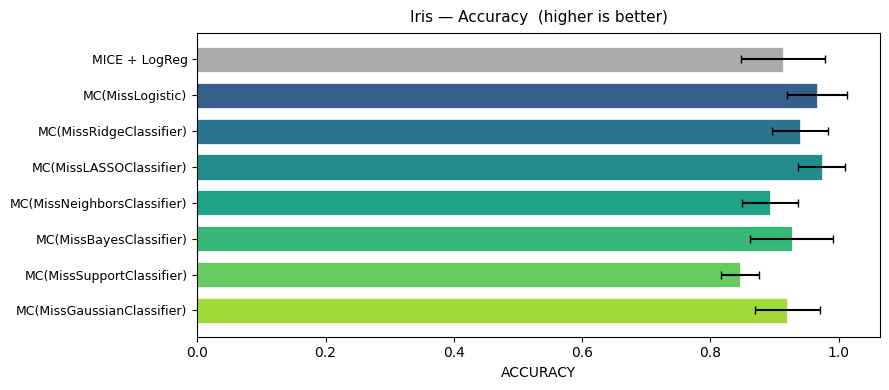

In [11]:
results_iris = bench_iris(plot=True)

---
## Tier 2: Real Missing Data
These datasets contain genuine missingness recorded during data collection.
No synthetic injection is applied.  This tier tests how FIML handles the
real-world missing-data distribution rather than a controlled synthetic one.
The key advantage of FIML; using all available information without
imputation; matters most here.

---
### 4. Auto MPG  (regression, real + synthetic MAR ~20%)Classic UCI dataset for predicting fuel efficiency.  Target: mpg.  Seven
features including horsepower, which has 6 missing values in the original
data (~1.5% of that column).  Because real missingness is too sparse to
differentiate methods, an additional 20% synthetic MAR is injected on top
of the real missingness, giving ~20% total missing across the feature matrix.
MissGaussianRegressor included (n=392 ≤ 400).

**Reference:** Quinlan (1993), UCI ML Repository  
**Defaults:** `miss_rate=0.20`, `n_splits=5`, `seed=42`

In [ ]:
results_mpg = bench_auto_mpg(plot=True)


  Auto MPG Benchmark  (Tier 2 — real missing data + synthetic MAR)
  n=398  p=7  real_miss=0.2%  injected_mar=20%  actual_miss=19.6%  cv=5  seed=42
  Dataset  : Auto MPG  |  Quinlan (1993), UCI ML Repository
  Task     : regression  |  target: fuel efficiency (mpg)
  Missingness: real (horsepower) + synthetic MAR at 20%

  Running 5-fold CV for 4 baselines + 7 MissLearn models ...


---
## Tier 3: Missingness Mechanism Sweep
The mechanism sweep tests whether FIML's advantage over imputation depends
on *how* data are missing, not just *how much*.  Three mechanisms are compared:

| Mechanism | Description | Identifiable? |
|-----------|-------------|---------------|
| MCAR | Uniform random deletion | Yes |
| MAR  | Missingness depends on other observed features | Yes |
| MNAR | Missingness depends on the missing value itself | No (without extra assumptions) |

Under MCAR and MAR, consistent estimation is possible; under MNAR, naive
imputation introduces systematic bias while FIML is better calibrated.

---
### 5. ESOL: Mechanism Sweep  (regression, MCAR / MAR / MNAR × [10%-50%])Delaney aqueous solubility dataset.  Target: measured log solubility
(mol/L).  Six molecular descriptors; n=1128 complete observations.
Flagship FIML models (MissLinear, MissRidgeRegressor) are compared against
CC + LinearReg and MICE + LinearReg across five missingness rates under each
of three mechanisms.  GP omitted (n=1128 > 400).

**Reference:** Delaney (2004), doi:10.1021/ci034243x  
**Defaults:** `mechanisms=['MCAR','MAR','MNAR']`, `miss_rates=[0.10,0.20,0.30,0.40,0.50]`

In [ ]:
results_esol = bench_esol_sweep(plot=True)

---
## Tier 4: Grouped / Longitudinal Data (MissMixed)
MissMixed adds a random intercept per group on top of FIML, making it a
full-information mixed-effects model.  Observations within the same group
share correlated errors; ignoring this structure inflates residual variance
and can produce miscalibrated standard errors and predictions.

To fairly evaluate MissMixed, Tier 4 uses the **Radon dataset** (Gelman &
Hill 2007); the canonical multilevel modeling benchmark.  919 Minnesota
household radon measurements are nested within 85 counties (median 11
obs/county).  County-level uranium concentration is an additional predictor.

The benchmark runs twice on the same data:
- **Regression:** continuous log radon level.
- **Classification:** above-median log radon (binary).

In both cases MissMixed is compared against four imputation baselines,
MissLinear/MissLogistic (FIML without random effects), and MissRidgeRegressor/
MissRidgeClassifier.  The random-intercept term should be most beneficial
when between-group variance is large relative to within-group variance.

---
### 6. Radon  (regression + binary classification, synthetic MAR 20%, 85 groups)919 household radon measurements from the Minnesota Residential Radon Survey
(US EPA, 1988 to 1992).  Features: floor of measurement (basement=0/first=1) and
county-level log uranium concentration (Uppm).  Groups: 85 Minnesota counties.

The benchmark isolates the contribution of random effects by comparing:
imputation baselines → FIML without random effects → FIML with random intercepts.

**Reference:** Gelman & Hill (2007). *Data Analysis Using Regression and
Multilevel/Hierarchical Models.* Cambridge University Press.  
**Defaults:** `miss_rate=0.20`, `n_splits=5`, `seed=42`

In [ ]:
results_mixed = bench_mixed(plot=True)

---
### Run All Benchmarks
Executes every benchmark sequentially with default parameters.

**Estimated runtime:** 2-8 hours depending on hardware.  
The Iris GP models are the slowest due to n³ Cholesky cost.  
Radon with MissMixed adds moderate overhead (GH quadrature per group).  
Run overnight or reduce `n_splits=3` for a faster pass.

In [ ]:
results_energy    = bench_energy_efficiency(plot=True)
results_wisconsin = bench_wisconsin(plot=True)
results_iris      = bench_iris(plot=True)
results_mpg       = bench_auto_mpg(plot=True)
results_esol      = bench_esol_sweep(plot=True)
results_mixed     = bench_mixed(plot=True)